# Funnel Drop-off Analysis

**Author:** Komalika Das

### Objective

The goal of this analysis is to understand how users move through the signup and checkout funnel, identify where the biggest drop-off happens, and measure the conversion rate between each stage.

**Funnel order:**

`visited_site → signup_started → details_filled → email_verified → purchase_completed`

### Steps followed

- Load the dataset and perform some basic data checks.
- Count the number of unique users at each stage.
- Calculate conversion between consecutive stages.
- Find the stage with the biggest user drop-off.
- Visualize the funnel.
- Explore a couple of additional insights such as conversion time and user segments.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.float_format", lambda x: f"{x:,.1f}")
# Expected funnel sequence
FUNNEL = ["visited_site", "signup_started", "details_filled",
          "email_verified", "purchase_completed"]

df = pd.read_csv("funnel_events_sample.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.head()

,user_id,step,timestamp
0,U036,details_filled,2026-07-20 04:28:00
1,U061,email_verified,2026-07-20 04:53:00
2,U071,email_verified,2026-07-20 04:23:00
3,U082,email_verified,2026-07-20 04:46:00
4,U182,details_filled,2026-07-20 04:10:00


## 1. Data Quality Checks

Before starting the analysis, I'll check if the dataset contains duplicate records, missing values, or unexpected funnel steps.

In [38]:
print(f"Rows: {len(df):,}")
print(f"Unique users: {df['user_id'].nunique():,}")
print(f"Fully-duplicated rows: {df.duplicated().sum()}")
print(f"Duplicate (user, step) events: {df.duplicated(subset=['user_id','step']).sum()}")
print(f"Missing values:\n{df.isna().sum().to_string()}")
# Check for unexpected funnel steps
unknown = set(df['step'].unique()) - set(FUNNEL)
print(f"\nUnknown / out-of-vocabulary steps: {unknown if unknown else 'none'}")

# Keep only the first occurrence of each user at every stage
df = (df.sort_values('timestamp')
        .drop_duplicates(subset=['user_id','step'], keep='first'))

Rows: 542
Unique users: 200
Fully-duplicated rows: 0
Duplicate (user, step) events: 0
Missing values:
user_id      0
step         0
timestamp    0

Unknown / out-of-vocabulary steps: none


In [40]:
# Check if users skip any funnel stages

rank = {step: i for i, step in enumerate(FUNNEL)}

seq = (
    df.assign(r=df["step"].map(rank))
      .groupby("user_id")["r"]
      .agg(["min", "max", "nunique"])
)

has_gap = (seq["max"] - seq["min"] + 1) != seq["nunique"]

print(f"Every user's first recorded stage is visited_site: {(seq['min'] == 0).all()}")
print(f"Users with skipped stages: {has_gap.sum()} out of {len(seq)} ({has_gap.mean() * 100:.1f}%)")

print("\nSome users reach later stages without every intermediate event being recorded.")
print("This doesn't affect the funnel because users are counted once for each stage they reach.")

Every user's first recorded stage is visited_site: True
Users with skipped stages: 146 out of 200 (73.0%)

Some users reach later stages without every intermediate event being recorded.
This doesn't affect the funnel because users are counted once for each stage they reach.


### Summary

- No duplicate or missing values were found.
- No unexpected funnel stages were present.
- Some users skipped intermediate stages in the event log, but this doesn't affect the unique user counts used for the funnel.

## 2. Users at Each Stage

Now I'll count the number of unique users at each funnel stage and calculate the conversion rate from one stage to the next.

In [44]:
stage_users = (df.groupby('step')['user_id'].nunique()
                 .reindex(FUNNEL))          # reindex enforces funnel order

funnel = pd.DataFrame({'unique_users': stage_users})
funnel['conversion_vs_prev_%'] = (funnel['unique_users'] /
                                  funnel['unique_users'].shift(1) * 100).round(1)
funnel['users_lost']  = (funnel['unique_users'].shift(1) - funnel['unique_users'])
funnel['drop_off_%']  = (funnel['users_lost'] /
                         funnel['unique_users'].shift(1) * 100).round(1)
funnel['overall_%']   = (funnel['unique_users'] /
                         funnel['unique_users'].iloc[0] * 100).round(1)
funnel

,unique_users,conversion_vs_prev_%,users_lost,drop_off_%,overall_%
step,,,,,
visited_site,200,NaN,NaN,NaN,100.0
signup_started,150,75.0,50.0,25.0,75.0
details_filled,96,64.0,54.0,36.0,48.0
email_verified,52,54.2,44.0,45.8,26.0
purchase_completed,44,84.6,8.0,15.4,22.0


## 3. Biggest Drop-off

Next, I'll identify which stage loses the highest number of users and which stage has the lowest conversion rate.

In [47]:
trans = funnel.dropna(subset=["drop_off_%"]).copy()

trans["transition"] = [
    f"{FUNNEL[i-1]} -> {FUNNEL[i]}"
    for i in range(1, len(FUNNEL))
]

by_pct = trans.loc[trans["drop_off_%"].idxmax()]
by_abs = trans.loc[trans["users_lost"].idxmax()]

print("Biggest Drop-off")
print("-" * 50)

print(f"Highest percentage drop : {by_pct['transition']}")
print(
    f"Users lost: {by_pct['drop_off_%']:.1f}% "
    f"(Conversion: {by_pct['conversion_vs_prev_%']:.1f}%)"
)

print()

print(f"Highest user loss       : {by_abs['transition']}")
print(f"Users lost: {int(by_abs['users_lost'])}")

print("-" * 50)
print(
    "The largest percentage drop occurs between details_filled and "
    "email_verified, where many users leave before verifying their email."
)

Biggest Drop-off
--------------------------------------------------
Highest percentage drop : details_filled -> email_verified
Users lost: 45.8% (Conversion: 54.2%)

Highest user loss       : signup_started -> details_filled
Users lost: 54
--------------------------------------------------
The largest percentage drop occurs between details_filled and email_verified, where many users leave before verifying their email.


## 4. Funnel Visualization

The chart below shows the number of users who reached each stage of the funnel.

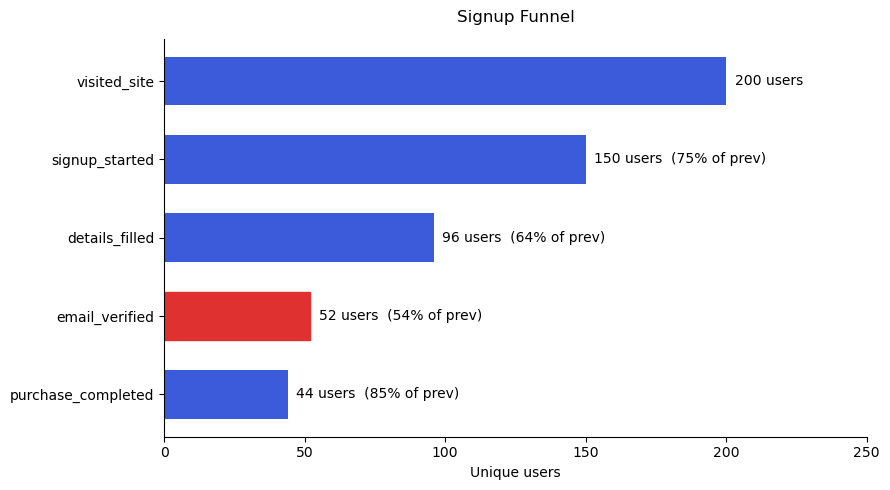

In [50]:
fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(FUNNEL))[::-1]
bars = ax.barh(y, funnel['unique_users'], color='#3b5bdb', height=0.62)

for i, (yy, stage) in enumerate(zip(y, FUNNEL)):
    n = funnel['unique_users'].iloc[i]
    label = f"{int(n)} users"
    if not np.isnan(funnel['conversion_vs_prev_%'].iloc[i]):
        label += f"  ({funnel['conversion_vs_prev_%'].iloc[i]:.0f}% of prev)"
    ax.text(n + 3, yy, label, va='center', fontsize=10)
# Highlight the stage after the biggest drop-off
worst_i = list(FUNNEL).index(by_pct.name)
bars[worst_i].set_color('#e03131')

ax.set_yticks(y); ax.set_yticklabels(FUNNEL)
ax.set_xlim(0, funnel['unique_users'].max() * 1.25)
ax.set_xlabel("Unique users")
ax.set_title("Signup Funnel",
             fontsize=12, pad=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("funnel_chart.png", dpi=130, bbox_inches='tight')
plt.show()

## Bonus: Time Between Stages

This calculates the average time users take to move from one stage to the next.

In [53]:
wide = df.pivot_table(index='user_id', columns='step',
                      values='timestamp', aggfunc='first')

rows = []
for a, b in zip(FUNNEL, FUNNEL[1:]):
    if a in wide and b in wide:
        delta = (wide[b] - wide[a]).dropna()
        delta = delta[delta >= pd.Timedelta(0)]   # ignore illogical negatives
        rows.append({'transition': f"{a} -> {b}",
                     'users_measured': len(delta),
                     'avg_minutes': round(delta.dt.total_seconds().mean()/60, 1),
                     'median_minutes': round(delta.dt.total_seconds().median()/60, 1)})
time_to_convert = pd.DataFrame(rows)
time_to_convert

,transition,users_measured,avg_minutes,median_minutes
0,visited_site -> signup_started,118,20.7,20.0
1,signup_started -> details_filled,36,21.6,20.5
2,details_filled -> email_verified,0,NaN,NaN
3,email_verified -> purchase_completed,0,NaN,NaN


## Bonus: Segment Comparison

As a simple example, I'll divide users into two groups using their user ID and compare their overall conversion.

In [56]:
num = df['user_id'].str.extract(r'(\d+)').astype(int)[0]
df['segment'] = np.where(num % 2 == 0, 'even_id', 'odd_id')

seg = (df.groupby(['segment','step'])['user_id'].nunique()
         .unstack()[FUNNEL])
seg['overall_conv_%'] = (seg['purchase_completed'] /
                         seg['visited_site'] * 100).round(1)
seg

step,visited_site,signup_started,details_filled,email_verified,purchase_completed,overall_conv_%
segment,,,,,,
even_id,100,75,48,26,22,22.0
odd_id,100,75,48,26,22,22.0


## Recommendation

The largest percentage drop happens between **details_filled** and **email_verified**, where many users leave before completing email verification.

A possible improvement would be to make email verification quicker and easier, such as using a one-click verification link or reminding users to verify their email. Since most verified users eventually complete their purchase, improving this step could increase the overall conversion rate.